### What is Hyperparameter Tuning?

`Hyperparameter tuning` is the process of finding the best set of hyperparameters (configuration settings) for a machine learning algorithm.

Unlike model parameters (learned from data), hyperparameters are set before training and control how the model learns.

The goal is to improve model performance (accuracy, precision, recall, RMSE, etc.) by choosing optimal hyperparameters.

### Parameters vs Hyperparameters  

### Parameters  
- Parameters are values **learned from the training data** by the model.  
- They are updated during training using optimization algorithms (like gradient descent).  
- They represent the "knowledge" the model has gained.  

#### Examples:
- **Linear Regression:** coefficients (weights) `β0, β1, β2, ...` and the intercept.  
- **Logistic Regression:** weights associated with each feature and the bias.    
- **KNN:** (no learned parameters, since it memorizes the dataset).  
- **decision trees:** these are the actual splits and structure the model creates.
- **SVM:** support vectors, weights, and bias learned from the data.
- **Naive Bayes:** Prior Probabilities and the probability of each feature given a class.

Example: In a Linear Regression equation:  
\[
y = β_0 + β_1x_1 + β_2x_2 + ... + β_nx_n
\]  
The `β`s are the **parameters** that the algorithm learns.  

### Hyperparameters  
- Hyperparameters are set **before training** and control how the model learns.  
- They are **not learned** from the data but chosen by the data scientist (sometimes tuned using GridSearch, Random Search, etc.).  

#### Examples:
- **Logistic Regression:** `C`, `penalty`, `solver`.  
- **Decision Trees:** `max_depth`, `min_samples_split`.  
- **KNN:** `n_neighbors`, `metric`.  
- **SVM:** `C`, `kernel`, `gamma`.  

#### Common Hyperparameter Tuning Methods

1. **Grid Search**
- Tries all possible combinations of hyperparameters.
- Computationally expensive.

2. **Random Search**
- Samples random combinations of hyperparameters.
- Faster than grid search and often effective.

### Examples of Hyperparameters  

#### 1. Linear Regression  
- `fit_intercept` – whether to calculate the intercept (boolean).  
- `normalize` – whether to normalize input features (deprecated in new versions).  

#### 2. Logistic Regression  
- `C` – inverse of regularization strength (smaller values = stronger regularization).  
- `penalty` – type of regularization (`l1`, `l2`, `elasticnet`, `none`).  
- `solver` – optimization algorithm (`liblinear`, `saga`, `newton-cg`, `lbfgs`).  
- `max_iter` – maximum number of iterations for convergence.  

#### 3. Decision Trees  
- `max_depth` – maximum depth of the tree.  
- `min_samples_split` – minimum number of samples required to split a node.  
- `min_samples_leaf` – minimum number of samples required at a leaf node.  
- `max_features` – number of features to consider for the best split.  
- `criterion` – function to measure split quality (`gini`, `entropy`).  

#### 4. Random Forest  
Includes all Decision Tree hyperparameters, plus:  
- `n_estimators` – number of trees in the forest.  
- `bootstrap` – whether bootstrap samples are used when building trees.  

#### 5. K-Nearest Neighbors (KNN)  
- `n_neighbors` – number of neighbors to consider.  
- `metric` – distance metric (`euclidean`, `manhattan`, `minkowski`).  
- `weights` – how to weight neighbors (`uniform`, `distance`).  

#### 6. Support Vector Machine (SVM)  
- `C` – regularization parameter.  
- `kernel` – type of kernel (`linear`, `rbf`, `poly`, `sigmoid`).  
- `gamma` – kernel coefficient (affects influence of a single training example).  
- `degree` – degree of polynomial kernel (if `poly`).  


### Implementation of Hyperparameter Tuning

### Import Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import learning_curve
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV


### Load Dataset

In [19]:
diabetes = load_diabetes()

X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target, name="disease_progression")

#### Basic Data Exploration (EDA)

In [5]:
print(X.shape)
print(X.head())

(442, 10)
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  
0 -0.002592  0.019907 -0.017646  
1 -0.039493 -0.068332 -0.092204  
2 -0.002592  0.002861 -0.025930  
3  0.034309  0.022688 -0.009362  
4 -0.002592 -0.031988 -0.046641  


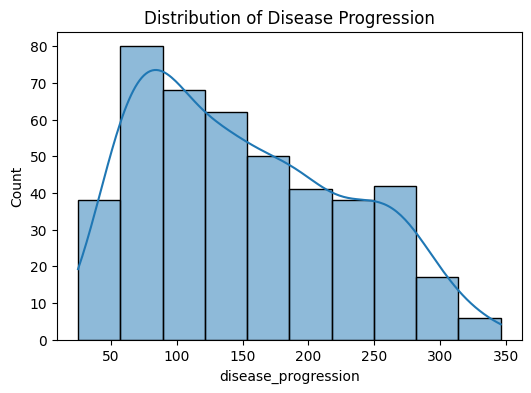

In [53]:
# Target distribution
plt.figure(figsize=(6,4))
sns.histplot(y, kde=True)
plt.title("Distribution of Disease Progression")
plt.show()

### Feature relationships

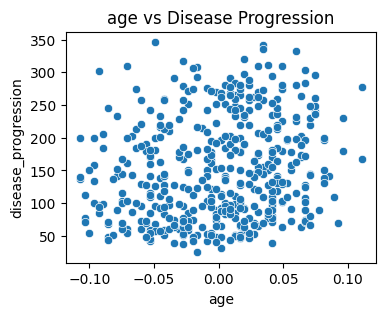

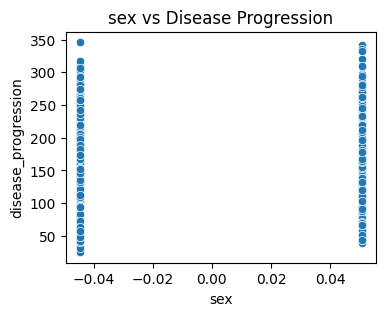

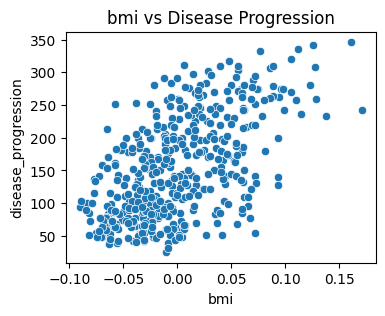

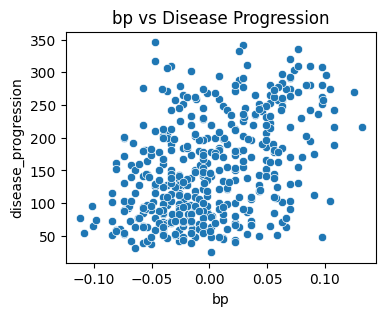

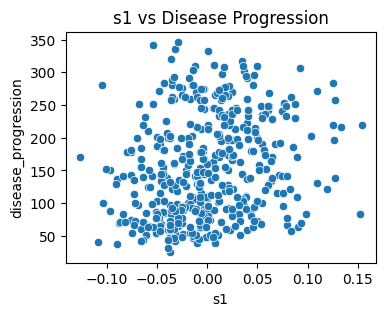

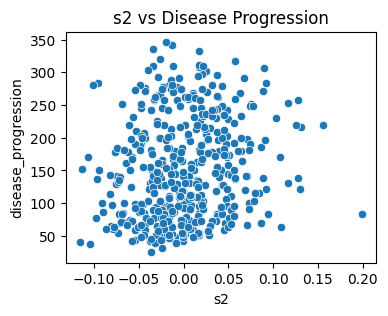

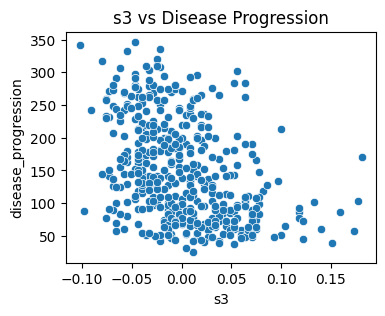

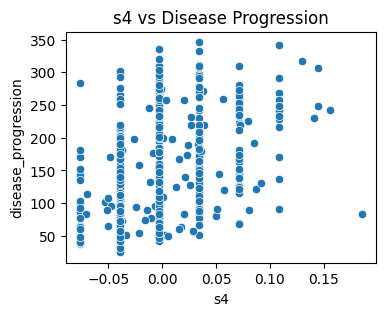

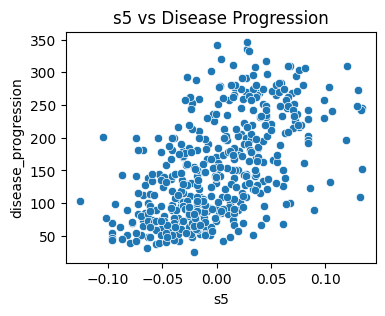

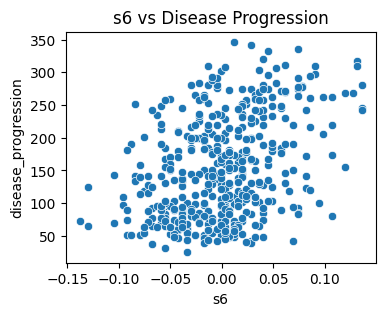

In [6]:
for col in X.columns:
    plt.figure(figsize=(4,3))
    sns.scatterplot(x=X[col], y=y)
    plt.title(f"{col} vs Disease Progression")
    plt.show()

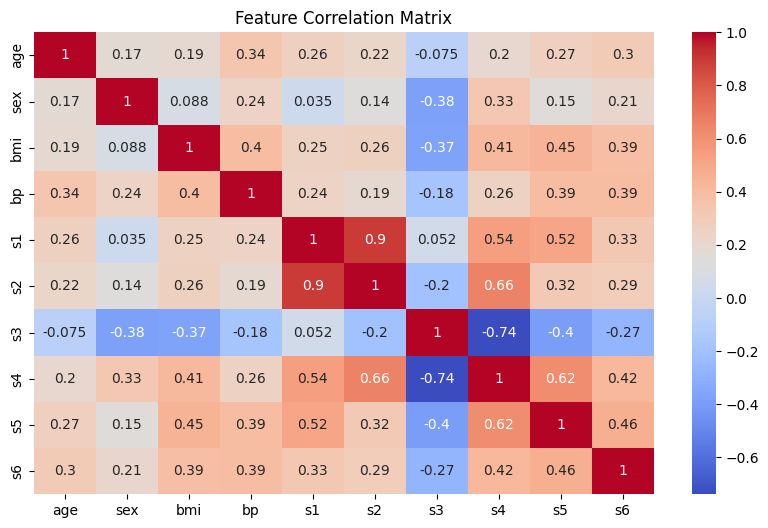

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(X.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Matrix")
plt.show()

### Check Linearity

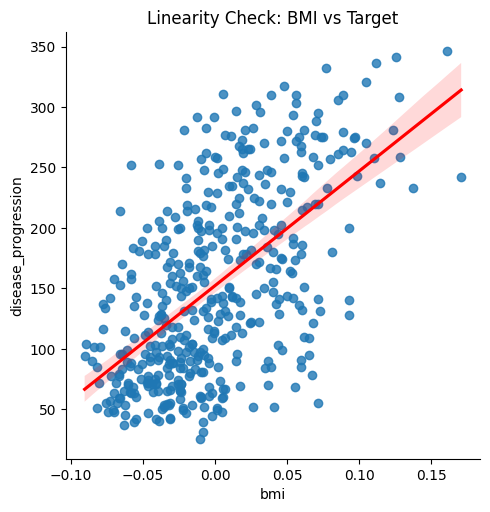

In [8]:
sns.lmplot(x="bmi", y=y.name, data=X.join(y), line_kws={"color":"red"})
plt.title("Linearity Check: BMI vs Target")
plt.show()

### Split Data

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Baseline Model (Linear Regression)

In [21]:
lr_model = LinearRegression()

scores = cross_val_score(
    lr_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Linear Regression R² scores:", scores)
print("Mean R²:", scores.mean())

Linear Regression R² scores: [0.54760189 0.36123934 0.50481226 0.61773622 0.21489265]
Mean R²: 0.44925647412212194


### Learning Curve for Linear Regression

In [22]:
train_sizes, train_scores, val_scores = learning_curve(
    lr_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

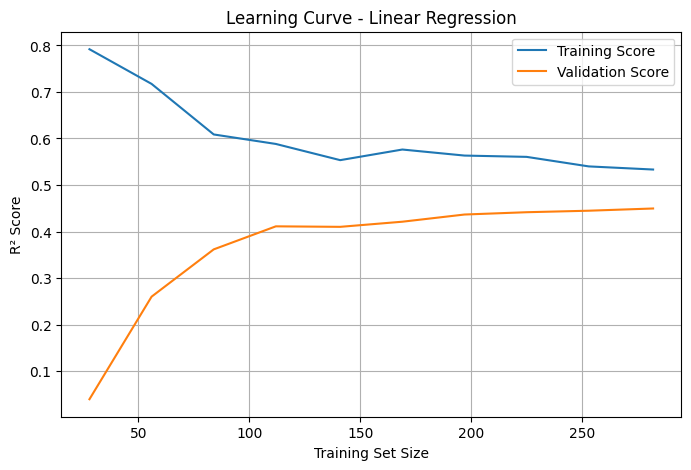

In [23]:
plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_scores.mean(axis=1), label="Training Score")
plt.plot(train_sizes, val_scores.mean(axis=1), label="Validation Score")

plt.title("Learning Curve - Linear Regression")
plt.xlabel("Training Set Size")
plt.ylabel("R² Score")
plt.legend()
plt.grid()
plt.show()

### Add Complexity  Polynomial Regression

In [24]:
poly_model = Pipeline([
    ('poly', PolynomialFeatures(degree=1)),
    ('linear', LinearRegression())
])

scores = cross_val_score(
    poly_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Polynomial Regression R² scores:", scores)
print("Polynomial (degree=1) R²:", scores.mean())

Polynomial Regression R² scores: [0.54760189 0.36123934 0.50481226 0.61773622 0.21489265]
Polynomial (degree=1) R²: 0.4492564741221218


### Add Regularization (Ridge & Lasso)
#### Ridge (controls large weights)

In [26]:
ridge_model = Pipeline([
    ('poly', PolynomialFeatures(degree=1)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=0.1))
])

scores = cross_val_score(
    ridge_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Ridge R²:", scores.mean())

Ridge R²: 0.44959099872396013


#### Lasso (feature selection effect)

In [27]:
lasso_model = Pipeline([
    ('poly', PolynomialFeatures(degree=1)),
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.5))
])

scores = cross_val_score(
    lasso_model,
    X_train,
    y_train,
    cv=5,
    scoring='r2'
)

print("Lasso R²:", scores.mean())

Lasso R²: 0.4529497943444751


### GRID SEARCH

In [11]:
pipeline = Pipeline([
    ('poly', PolynomialFeatures()),
    ('ridge', Ridge())
])

param_grid = {
    'poly__degree': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'ridge__alpha': [0.01, 0.1, 1, 2, 5, 6, 8]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters (Grid Search):")
print(grid_search.best_params_)

print("Best CV Score:", grid_search.best_score_)

Best Parameters (Grid Search):
{'poly__degree': 2, 'ridge__alpha': 0.1}
Best CV Score: 0.45650862593863595


### RANDOM SEARCH

We `randint, uniform` to define probability distributions for hyperparameters in Random Search.

In [12]:
from scipy.stats import randint, uniform
param_dist = {
    'poly__degree': randint(1, 10),
    'ridge__alpha': uniform(0.01, 10)
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best Parameters (Random Search):")
print(random_search.best_params_)

print("Best CV Score:", random_search.best_score_)

Best Parameters (Random Search):
{'poly__degree': 6, 'ridge__alpha': np.float64(0.017787658410143285)}
Best CV Score: 0.4537450726642943


### Best model selection

In [14]:
best_model = random_search.best_estimator_

### Final evaluation (ONLY ON TEST SET)

In [15]:
y_pred = best_model.predict(X_test)
print("Test R²:", r2_score(y_test, y_pred))

Test R²: 0.4769283419660527


### Error Analysis

After training your best model, you now ask:

> `Where is my model making the biggest mistakes, and why?`

You are analyzing:

- How far predictions are from true values
- Whether errors are systematic or random
- Which cases are hardest to predict

### Compute errors (residuals)

In [28]:
errors = y_test - y_pred

#### Distribution of errors

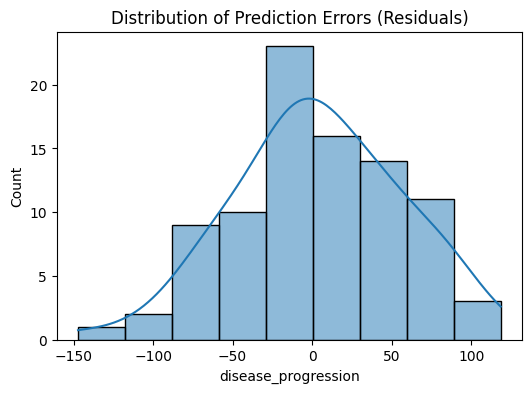

In [29]:
plt.figure(figsize=(6,4))
sns.histplot(errors, kde=True)
plt.title("Distribution of Prediction Errors (Residuals)")
plt.show()

#### Actual vs Predicted

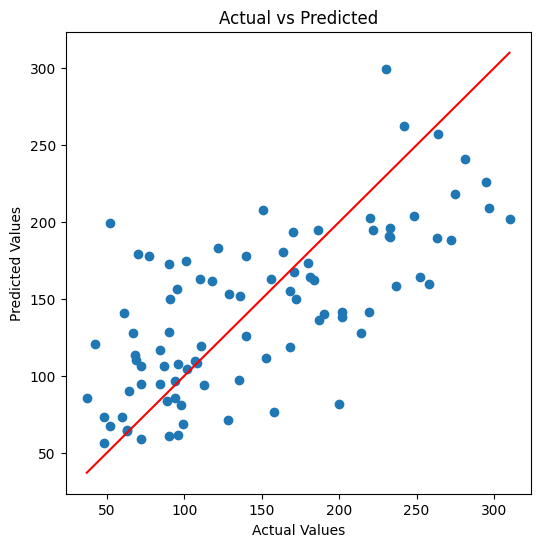

In [30]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.show()

#### Residual plot

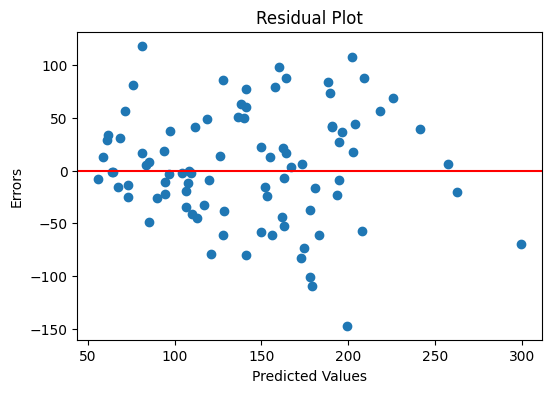

In [31]:
plt.figure(figsize=(6,4))
plt.scatter(y_pred, errors)
plt.axhline(y=0, color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Errors")
plt.title("Residual Plot")
plt.show()

#### Find worst predictions

In [34]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred,
    "Error": errors,
    "Abs_Error": np.abs(errors)
})

results.sort_values(by="Abs_Error", ascending=False).head(10)

,Actual,Predicted,Error,Abs_Error
56,52.0,199.157612,-147.157612,147.157612
77,200.0,81.417260,118.582740,118.582740
211,70.0,179.386430,-109.386430,109.386430
9,310.0,202.207657,107.792343,107.792343
209,77.0,177.828714,-100.828714,100.828714
395,258.0,159.893477,98.106523,98.106523
113,297.0,208.952060,88.047940,88.047940
78,252.0,164.196780,87.803220,87.803220
218,214.0,127.940182,86.059818,86.059818
354,272.0,188.192557,83.807443,83.807443


#### actual observations (feature rows X) behind those worst errors.

In [35]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Error": y_test.values - y_pred,
    "Abs_Error": np.abs(y_test.values - y_pred)
})

#### Attach original features

In [36]:
results_with_features = X_test.copy()
results_with_features["Actual"] = y_test.values
results_with_features["Predicted"] = y_pred
results_with_features["Error"] = y_test.values - y_pred
results_with_features["Abs_Error"] = np.abs(y_test.values - y_pred)

In [37]:
worst_cases = results_with_features.sort_values(by="Abs_Error", ascending=False).head(10)
worst_cases

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,Actual,Predicted,Error,Abs_Error
56,-0.041840,-0.044642,0.041218,-0.026328,-0.031840,-0.030437,-0.036038,0.002943,0.033654,-0.017646,52.0,199.157612,-147.157612,147.157612
77,-0.096328,-0.044642,-0.036385,-0.074527,-0.038720,-0.027618,0.015505,-0.039493,-0.074093,-0.001078,200.0,81.417260,118.582740,118.582740
211,0.092564,-0.044642,0.036907,0.021872,-0.024960,-0.016658,0.000779,-0.039493,-0.022517,-0.021788,70.0,179.386430,-109.386430,109.386430
9,-0.070900,-0.044642,0.039062,-0.033213,-0.012577,-0.034508,-0.024993,-0.002592,0.067737,-0.013504,310.0,202.207657,107.792343,107.792343
209,0.038076,0.050680,-0.018062,0.066629,-0.051103,-0.016658,-0.076536,0.034309,-0.011897,-0.013504,77.0,177.828714,-100.828714,100.828714
395,-0.060003,-0.044642,0.001339,-0.029770,-0.007073,-0.021669,0.011824,-0.002592,0.031812,-0.054925,258.0,159.893477,98.106523,98.106523
113,0.019913,0.050680,0.014272,0.063187,0.014942,0.020293,-0.047082,0.034309,0.046662,0.090049,297.0,208.952060,88.047940,88.047940
78,0.005383,-0.044642,-0.057941,-0.022885,-0.067615,-0.068328,-0.054446,-0.002592,0.042897,-0.083920,252.0,164.196780,87.803220,87.803220
218,-0.041840,-0.044642,-0.065486,-0.040099,-0.005697,0.014344,-0.043401,0.034309,0.007027,-0.013504,214.0,127.940182,86.059818,86.059818
354,-0.023677,0.050680,0.045529,0.021872,0.109883,0.088873,0.000779,0.034309,0.074191,0.061054,272.0,188.192557,83.807443,83.807443
